# Build Adjacency Matrices
Shared by all 3 model permutations. Builds:
- Sparse line-graph adjacency (COO) per corridor → used by GWN
- Chebyshev polynomials K=3 per corridor → used by STGCN
- Global edge_id → integer index map → used by all models for embedding lookup

In [1]:
import os, pickle, time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

STATIC_PATH = '../data generation/data/processed/edges_static_scaled.parquet'
OUT_DIR     = '../data generation/data/graph_adj'
os.makedirs(OUT_DIR, exist_ok=True)
CHEB_K = 3

df = pd.read_parquet(STATIC_PATH)
print(f'Edges: {len(df):,}  Corridors: {df.corridor_id.nunique()}')
df.head(3)

Edges: 145,265  Corridors: 24


,edge_id,u,v,lat,lon,zone_id,corridor_id,free_flow_speed,road_length,signals_per_km,traffic_signal_count,intersection_count,road_type_enc,num_lanes,oneway
0,245654691_1034965549_0,245654691,1034965549,18.946730,72.832634,0,0,50.0,0.035074,0.027613,0.5,0.5,0.571429,0.2,1
1,245654725_245654739_0,245654725,245654739,18.947941,72.795761,1,0,30.0,0.010241,0.000000,0.0,1.0,0.142857,0.0,0
2,245654725_245654775_0,245654725,245654775,18.947542,72.794823,1,0,30.0,0.083199,0.000000,0.0,1.0,0.142857,0.0,0


In [2]:
# Global edge_id -> integer index (for edge embedding lookup in model)
df_sorted = df.sort_values('edge_id').reset_index(drop=True)
edge_to_global_idx = {eid: i for i, eid in enumerate(df_sorted['edge_id'])}
print(f'Global map size: {len(edge_to_global_idx):,}')
with open(f'{OUT_DIR}/edge_to_global_idx.pkl', 'wb') as f:
    pickle.dump(edge_to_global_idx, f)
print('Saved edge_to_global_idx.pkl')

Global map size: 145,265
Saved edge_to_global_idx.pkl


In [3]:
def build_line_graph_adj(corr_df):
    """
    Line graph: road segment i=(u->v) connects to j=(v->w).
    Traffic flows through shared node v: i->j in line graph.
    We also add reverse j->i for undirected signal propagation.
    """
    edge_ids = corr_df['edge_id'].tolist()
    local_map = {eid: i for i, eid in enumerate(edge_ids)}
    N = len(edge_ids)
    u_arr = corr_df['u'].values
    v_arr = corr_df['v'].values

    end_at   = {}  # node -> edges ending here
    start_at = {}  # node -> edges starting here
    for i, (u, v) in enumerate(zip(u_arr, v_arr)):
        end_at.setdefault(int(v), []).append(i)
        start_at.setdefault(int(u), []).append(i)

    rows, cols = [], []
    for node in set(end_at) & set(start_at):
        for i in end_at[node]:
            for j in start_at[node]:
                if i != j:
                    rows += [i, j]   # both directions
                    cols += [j, i]

    return np.array(rows, np.int32), np.array(cols, np.int32), local_map, N


def normalize_adj(rows, cols, N):
    """GWN transition matrices: A_fwd=D_out^-1 A,  A_bwd=D_in^-1 A^T"""
    if len(rows) == 0:
        empty = sp.csr_matrix((N, N), dtype=np.float32)
        return empty, empty
    A = sp.coo_matrix((np.ones(len(rows), np.float32), (rows, cols)), (N, N)).tocsr()
    d_out = np.array(A.sum(1)).flatten(); d_out[d_out==0] = 1
    A_fwd = (sp.diags(1/d_out) @ A).astype(np.float32)
    AT = A.T.tocsr()
    d_in  = np.array(AT.sum(1)).flatten(); d_in[d_in==0] = 1
    A_bwd = (sp.diags(1/d_in) @ AT).astype(np.float32)
    return A_fwd, A_bwd


def compute_chebyshev(A_fwd, K):
    """Chebyshev polynomials T_0..T_K of scaled Laplacian, returns list of [N,N] arrays."""
    N = A_fwd.shape[0]
    if A_fwd.nnz == 0:
        return [np.eye(N, dtype=np.float32)] * (K + 1)
    A_sym = ((A_fwd + A_fwd.T) / 2).tocsr()
    d = np.array(A_sym.sum(1)).flatten(); d[d==0] = 1
    D_isqrt = sp.diags(1 / np.sqrt(d))
    L_hat = (sp.eye(N) - D_isqrt @ A_sym @ D_isqrt).toarray().astype(np.float32)
    # Scale: approximate lambda_max=2, so L_hat = L - I
    T = [np.eye(N, dtype=np.float32), L_hat]
    for k in range(2, K + 1):
        T.append(np.clip(2 * L_hat @ T[-1] - T[-2], -10, 10))
    return T

print('Helper functions defined.')

Helper functions defined.


In [5]:
# ── Main loop: process each corridor and save immediately ────────────────────
# WHY per-file saving:
#   Dense Chebyshev matrices for large corridors (N~9000) are ~1.3 GB each.
#   Accumulating all corridors in one dict then pickling = MemoryError.
#   Instead: process → save → del → gc after each corridor.
#   Training notebooks load one corridor at a time from these files.

import gc

corridor_meta = {}   # lightweight: edge_ids, local_map, global_indices, N only
corridors     = sorted(df['corridor_id'].unique())
CHEB_DENSE_MAX = 3000   # store dense Cheb only for corridors smaller than this
print(f"Processing {len(corridors)} corridors — saving per-corridor adj files ...")
t0 = time.perf_counter()

for cid in corridors:
    cdf = df[df['corridor_id'] == cid][['edge_id','u','v']].reset_index(drop=True)
    rows, cols, local_map, N = build_line_graph_adj(cdf)
    A_fwd, A_bwd = normalize_adj(rows, cols, N)

    # ── Chebyshev polys for STGCN ─────────────────────────────────────────────
    # Only compute full dense Cheb for small corridors.
    # For large corridors (N > CHEB_DENSE_MAX): store only T_0=I and T_1=L_hat.
    # STGCN will use K=min(CHEB_K, available_polys) automatically.
    if N <= CHEB_DENSE_MAX:
        cheb = compute_chebyshev(A_fwd, CHEB_K)   # list of K+1 dense [N,N] arrays
    elif N <= 5000:
        cheb = compute_chebyshev(A_fwd, 1)         # only T_0 + T_1 — 2 matrices
    else:
        # Very large corridor: T_0 = I only (64 MB for N=9000 is still fine)
        cheb = [np.eye(N, dtype=np.float32)]        # 1 matrix

    # ── Global embedding indices ──────────────────────────────────────────────
    global_indices = np.array(
        [edge_to_global_idx[eid] for eid in cdf['edge_id'].tolist()], np.int64
    )

    # ── Lightweight meta (kept in RAM, tiny) ──────────────────────────────────
    corridor_meta[cid] = {
        'edge_ids'      : cdf['edge_id'].tolist(),
        'local_map'     : local_map,
        'global_indices': global_indices,
        'N'             : N,
    }

    # ── Heavy adj data → save to individual file immediately ─────────────────
    A_fwd_coo = A_fwd.tocoo()
    A_bwd_coo = A_bwd.tocoo()
    adj_data  = {
        'A_fwd_dense': A_fwd.toarray() if N <= CHEB_DENSE_MAX else None,
        'A_bwd_dense': A_bwd.toarray() if N <= CHEB_DENSE_MAX else None,
        'A_fwd_coo'  : (A_fwd_coo.row.copy(), A_fwd_coo.col.copy(), A_fwd_coo.data.copy()),
        'A_bwd_coo'  : (A_bwd_coo.row.copy(), A_bwd_coo.col.copy(), A_bwd_coo.data.copy()),
        'cheb'        : cheb,
        'N'           : N,
    }

    corr_file = f'{OUT_DIR}/corridor_{cid:04d}.pkl'
    with open(corr_file, 'wb') as f:
        pickle.dump(adj_data, f, protocol=pickle.HIGHEST_PROTOCOL)

    nnz     = len(rows)
    density = nnz / max(N*N, 1) * 100
    n_cheb  = len(cheb)
    cheb_mb = sum(c.nbytes for c in cheb) / 1e6
    print(f'  Corridor {cid:3d}: N={N:6,}  nnz={nnz:7,}  density={density:.2f}%  ' 
          f'cheb_polys={n_cheb}  cheb_size={cheb_mb:.1f}MB  → {os.path.basename(corr_file)}')

    # Free immediately — do NOT accumulate heavy adj in RAM
    del adj_data, cheb, A_fwd, A_bwd, A_fwd_coo, A_bwd_coo
    gc.collect()

print(f'\nDone in {time.perf_counter()-t0:.1f}s')

# ── Save lightweight meta (tiny, always fits in RAM) ──────────────────────────
with open(f'{OUT_DIR}/corridor_meta.pkl', 'wb') as f:
    pickle.dump(corridor_meta, f, protocol=pickle.HIGHEST_PROTOCOL)

# ── Save corridor file index so training notebooks know what files exist ───────
corridor_file_index = {
    cid: f'{OUT_DIR}/corridor_{cid:04d}.pkl'
    for cid in corridors
}
with open(f'{OUT_DIR}/corridor_file_index.pkl', 'wb') as f:
    pickle.dump(corridor_file_index, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'Saved corridor_meta.pkl ({len(corridor_meta)} corridors)')
print(f'Saved corridor_file_index.pkl')
print(f'Saved {len(corridors)} individual corridor_XXXX.pkl files')
print(f'\nOutput directory: {OUT_DIR}/')


Processing 24 corridors — saving per-corridor adj files ...
  Corridor   0: N=10,196  nnz= 51,754  density=0.05%  cheb_polys=1  cheb_size=415.8MB  → corridor_0000.pkl
  Corridor   1: N= 4,385  nnz= 22,014  density=0.11%  cheb_polys=2  cheb_size=153.8MB  → corridor_0001.pkl
  Corridor   2: N=17,971  nnz= 92,850  density=0.03%  cheb_polys=1  cheb_size=1291.8MB  → corridor_0002.pkl
  Corridor   3: N= 8,887  nnz= 45,354  density=0.06%  cheb_polys=1  cheb_size=315.9MB  → corridor_0003.pkl
  Corridor   4: N= 6,443  nnz= 33,902  density=0.08%  cheb_polys=1  cheb_size=166.0MB  → corridor_0004.pkl
  Corridor   5: N= 8,337  nnz= 44,968  density=0.06%  cheb_polys=1  cheb_size=278.0MB  → corridor_0005.pkl
  Corridor   6: N= 5,394  nnz= 29,580  density=0.10%  cheb_polys=1  cheb_size=116.4MB  → corridor_0006.pkl
  Corridor   7: N= 4,417  nnz= 24,054  density=0.12%  cheb_polys=2  cheb_size=156.1MB  → corridor_0007.pkl
  Corridor   8: N= 9,037  nnz= 48,388  density=0.06%  cheb_polys=1  cheb_size=326.7

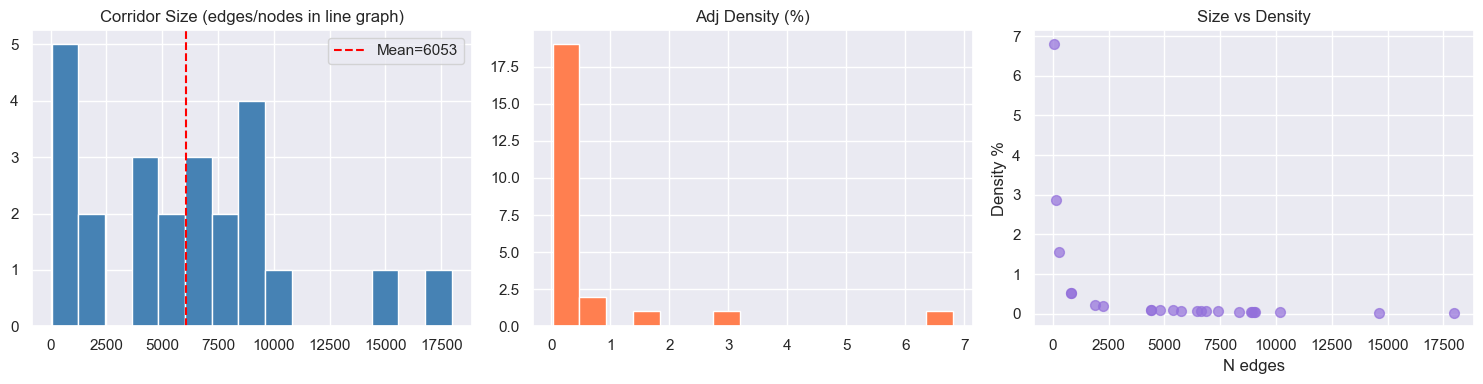

Min/Max corridor size : 52 / 17971
Mean size             : 6053
Mean adj density      : 0.575%

Files written:
  ../data generation/data/graph_adj/corridor_meta.pkl
  ../data generation/data/graph_adj/corridor_file_index.pkl
  ../data generation/data/graph_adj/corridor_0000.pkl ... corridor_0023.pkl

build_adj COMPLETE. Ready for training.


In [6]:
# ── Stats & Visualization ────────────────────────────────────────────────────
# Load sizes from meta (lightweight) — no need to load heavy adj files

sizes = [corridor_meta[c]['N'] for c in corridors]

# For density stats: load adj files one at a time, grab nnz, then discard
densities = []
for cid in corridors:
    corr_file = f'{OUT_DIR}/corridor_{cid:04d}.pkl'
    with open(corr_file, 'rb') as f:
        adj = pickle.load(f)
    r, c_idx, _ = adj['A_fwd_coo']
    N = adj['N']
    densities.append(len(r) / max(N*N, 1) * 100)
    del adj
    gc.collect()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sizes, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(sizes), color='red', ls='--', label=f'Mean={np.mean(sizes):.0f}')
axes[0].set_title('Corridor Size (edges/nodes in line graph)'); axes[0].legend()

axes[1].hist(densities, bins=15, color='coral', edgecolor='white')
axes[1].set_title('Adj Density (%)')

axes[2].scatter(sizes, densities, alpha=0.7, color='mediumpurple', s=50)
axes[2].set_xlabel('N edges'); axes[2].set_ylabel('Density %'); axes[2].set_title('Size vs Density')

plt.tight_layout(); plt.show()

print(f'Min/Max corridor size : {min(sizes)} / {max(sizes)}')
print(f'Mean size             : {np.mean(sizes):.0f}')
print(f'Mean adj density      : {np.mean(densities):.3f}%')
print(f'\nFiles written:')
print(f'  {OUT_DIR}/corridor_meta.pkl')
print(f'  {OUT_DIR}/corridor_file_index.pkl')
print(f'  {OUT_DIR}/corridor_0000.pkl ... corridor_{max(corridors):04d}.pkl')
print(f'\nbuild_adj COMPLETE. Ready for training.')
